In [1]:
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 142.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully uninstalled typer-0.27.1


In [ ]:
!pip install roboflow python-dotenv

import os
from getpass import getpass

from dotenv import load_dotenv

load_dotenv()  # picks up HG_ROBOFLOW_API_KEY from a local .env (not committed)

api_key = os.getenv("HG_ROBOFLOW_API_KEY")
if not api_key:
    # Colab: read it from the secrets panel, otherwise prompt without echoing
    try:
        from google.colab import userdata

        api_key = userdata.get("HG_ROBOFLOW_API_KEY")
    except Exception:
        api_key = None
if not api_key:
    api_key = getpass("Roboflow API key: ")

from roboflow import Roboflow

rf = Roboflow(api_key=api_key)
project = rf.workspace("joseph-nelson").project("hard-hat-workers")
version = project.version(2)
dataset = version.download("yolov8")

In [3]:
!cat {dataset.location}/data.yaml

names:
- head
- helmet
- person
nc: 3
roboflow:
  license: Public Domain
  project: hard-hat-workers
  url: https://universe.roboflow.com/joseph-nelson/hard-hat-workers/dataset/2
  version: 2
  workspace: joseph-nelson
test: ../test/images
train: ../train/images
val: ../valid/images


0 - head : head without helmet

1 - helmet : head with a helmet on

2 - person : whole body

In [4]:
from collections import Counter
import glob, os

for split in ["train", "valid", "test"]:
  counter = Counter()
  label_files = glob.glob(f"{dataset.location}/{split}/labels/*.txt")
  for f in label_files:
    with open(f) as fh:
      for line in fh:
        if line.strip():
          counter[int(line.split()[0])] += 1
  names = ["head", "helmet", "person"]
  print(f"\n{split.upper()}  ({len(label_files)} image)")
  for i, n in enumerate(names):
    print(f"  {n:8s}: {counter[i]}")


TRAIN  (5269 image)
  head    : 4874
  helmet  : 14884
  person  : 473

VALID  (0 image)
  head    : 0
  helmet  : 0
  person  : 0

TEST  (1766 image)
  head    : 1803
  helmet  : 4863
  person  : 142


valid file is empty we need to create it through train data. We seperate %15 of the train to validation

In [5]:
import os, glob, random, shutil

random.seed(42)
root = dataset.location

train_imgs = sorted(glob.glob(f"{root}/train/images/*"))
print("bulunan görsel:", len(train_imgs))

random.shuffle(train_imgs)
n_val = int(len(train_imgs) * 0.15)
val_imgs = train_imgs[:n_val]
print("taşınacak:", n_val)

os.makedirs(f"{root}/valid/images", exist_ok=True)
os.makedirs(f"{root}/valid/labels", exist_ok=True)

for img in val_imgs:
    base = os.path.splitext(os.path.basename(img))[0]
    lbl = f"{root}/train/labels/{base}.txt"
    shutil.move(img, f"{root}/valid/images/{os.path.basename(img)}")
    if os.path.exists(lbl):
        shutil.move(lbl, f"{root}/valid/labels/{base}.txt")

print("train:", len(glob.glob(f'{root}/train/images/*')))
print("valid:", len(glob.glob(f'{root}/valid/images/*')))

bulunan görsel: 5269
taşınacak: 790
train: 4479
valid: 790


In [6]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data=f"{root}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="kasket_v1",
    patience=10
)

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Hard-Hat-Workers-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=kasket_v1, nbs=64, nms=None, opset=None

In [7]:
from google.colab import files
files.download("/content/runs/detect/kasket_v1/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
files.download("/content/runs/detect/kasket_v1/results.png")
files.download("/content/runs/detect/kasket_v1/confusion_matrix_normalized.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


0: 640x640 1 helmet, 6.5ms
1: 640x640 4 heads, 6.5ms
2: 640x640 1 helmet, 6.5ms
3: 640x640 8 heads, 6.5ms
Speed: 5.0ms preprocess, 6.5ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


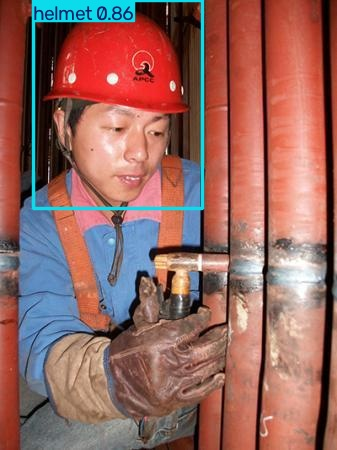

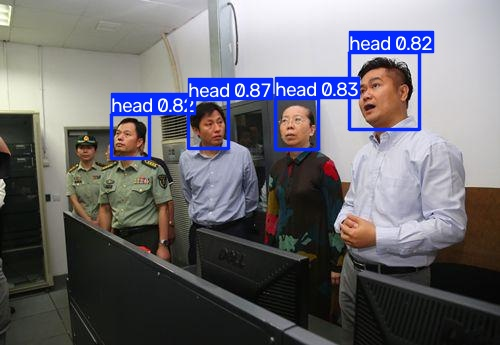

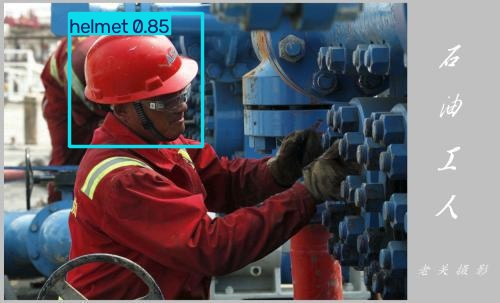

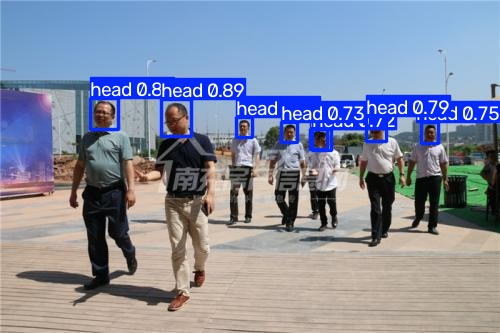

In [9]:
from ultralytics import YOLO
import glob, random
from IPython.display import Image, display

model = YOLO("/content/runs/detect/kasket_v1/weights/best.pt")
samples = random.sample(glob.glob(f"{root}/test/images/*"), 4)

results = model.predict(samples, conf=0.5, save=True, classes=[0, 1])
for r in results:
    display(Image(filename=r.save_dir + "/" + r.path.split("/")[-1], width=500))